# eBay Car Sales

#### Step 1 Inspecting the data through EDA

In [66]:
import pandas as pd
autos = pd.read_csv('../dataset/autos.csv',encoding="Latin-1")
print(autos.shape)
autos.head()
autos.info()


(371528, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    

In [67]:
#Checking for nulls
autos.isnull().sum()

dateCrawled                0
name                       0
seller                     0
offerType                  0
price                      0
abtest                     0
vehicleType            37869
yearOfRegistration         0
gearbox                20209
powerPS                    0
model                  20484
kilometer                  0
monthOfRegistration        0
fuelType               33386
brand                      0
notRepairedDamage      72060
dateCreated                0
nrOfPictures               0
postalCode                 0
lastSeen                   0
dtype: int64

#### Step 2 Cleaning cells and convert to snake_case

In [68]:
#Re-naming the coloumns
column_mapping = {
        "dateCrawled": "date_crawled",
    "offerType": "offer_type",
    "vehicleType": "vehicle_type",
    "yearOfRegistration": "registration_year",
    "powerPS": "power_ps",
    "monthOfRegistration": "registration_month",
    "fuelType": "fuel_type",
    "notRepairedDamage": "unrepaired_damage",
    "dateCreated": "date_created",
    "nrOfPictures": "num_pictures",
    "postalCode": "postal_code",
    "lastSeen": "last_seen"
}
autos.rename(columns=column_mapping, inplace=True)

In [69]:
#Validation
autos.columns

Index(['date_crawled', 'name', 'seller', 'offer_type', 'price', 'abtest',
       'vehicle_type', 'registration_year', 'gearbox', 'power_ps', 'model',
       'kilometer', 'registration_month', 'fuel_type', 'brand',
       'unrepaired_damage', 'date_created', 'num_pictures', 'postal_code',
       'last_seen'],
      dtype='object')

#### Step 3 Handling outliers in price, mileage and registration year

In [70]:
# Checking some columns for outliers for price, kilometers and registration_year
autos['price'].describe()


count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64

In [71]:
autos['kilometer'].describe()

count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

In [72]:
autos['registration_year'].describe()

count    371528.000000
mean       2004.577997
std          92.866598
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: registration_year, dtype: float64

Initial data quality assessment identified significant outliers in both the price and registration year fields. Vehicle prices ranged from £0 to over £2.1 billion, indicating unrealistic values that could heavily distort average price calculations. Registration years ranged from 1000 to 9999, including impossible historical dates and future years beyond the dataset collection period (2016). These outliers were flagged for further investigation and cleaning before conducting pricing and vehicle age analyses.

In [73]:
# Checking the top and bottom 20 for Sales
autos['price'].value_counts().sort_index().head(20)


price
0     10778
1      1189
2        12
3         8
4         1
5        26
7         3
8         9
9         8
10       84
11        5
12        8
13        7
14        5
15       27
16        2
17        5
18        3
19        3
20       51
Name: count, dtype: int64

In [74]:
autos['price'].value_counts().sort_index().tail(20)


price
1234566        1
1250000        2
1300000        1
1600000        2
2795000        1
2995000        1
3890000        1
3895000        1
9999999        3
10000000       8
10010011       1
11111111      10
12345678       9
14000500       1
27322222       1
32545461       1
74185296       1
99000000       1
99999999      15
2147483647     1
Name: count, dtype: int64

In [75]:
#Checking for Top 20 and Bottom 20 for 
autos['registration_year'].value_counts().sort_index().head(20)

registration_year
1000     38
1001      1
1039      1
1111      4
1200      1
1234      4
1253      1
1255      1
1300      2
1400      1
1500      5
1600      2
1602      1
1688      1
1800      5
1910    104
1911      1
1915      1
1919      1
1920      1
Name: count, dtype: int64

In [76]:
autos['registration_year'].value_counts().sort_index().tail(20)

registration_year
5900     1
5911     2
6000     6
6200     1
6500     1
7000     4
7100     1
7500     2
7777     1
7800     1
8000     2
8200     1
8455     1
8500     1
8888     2
9000     5
9229     1
9450     1
9996     1
9999    27
Name: count, dtype: int64

In [77]:
# Assuming the dataset year is 2026 - keeping the reg year from 1900 to 2026 and removing outliers outside of these years.
autos = autos[
    (autos['registration_year'] >= 1900) &
    (autos['registration_year'] <= 2026)
]

In [78]:
# Cleaning the price column to remove prices below 100 as most may be placeholders and those above 100,000
autos = autos[
    (autos["price"] >= 100) &
    (autos["price"] <= 100000)
]

In [79]:
autos.shape

(357683, 20)

Registration years below 1900 and above 2026 were removed as they represent impossible historical dates and future registrations. Vehicle prices below £100 were treated as placeholder or invalid values, while prices above £100,000 were considered unrealistic for a used-car marketplace and removed. These filtering rules reduced the influence of erroneous records and improved the reliability of subsequent analyses.

Outlier filtering removed 13,845 records (3.7% of the dataset). The cleaning process focused on unrealistic vehicle prices and invalid registration years while preserving the vast majority of listings. This ensured that subsequent analyses were based on plausible market values and vehicle ages.

#### Step 4 Exploring the relationship between price, brand, mileadge and age

In [80]:
# Using a clean dataset
autos_clean = autos[
    (autos["price"] >= 100) &
    (autos["price"] <= 100000) &
    (autos["registration_year"] >= 1900) &
    (autos["registration_year"] <= 2026)
].copy()

In [81]:
# Price vs Brand
brand_price = (
    autos_clean
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_price.head(15))

brand
porsche           34154.927109
land_rover        16602.378808
jaguar            12233.358586
sonstige_autos    11835.950845
jeep              11130.555128
mini               9972.737989
audi               8969.194197
bmw                8355.160811
mercedes_benz      8332.178967
chevrolet          7119.475924
skoda              6477.128754
dacia              5918.533784
kia                5811.065541
hyundai            5520.930928
volkswagen         5346.660388
Name: price, dtype: float64


<Axes: title={'center': 'Top 10 Brands by Average Price'}, xlabel='brand'>

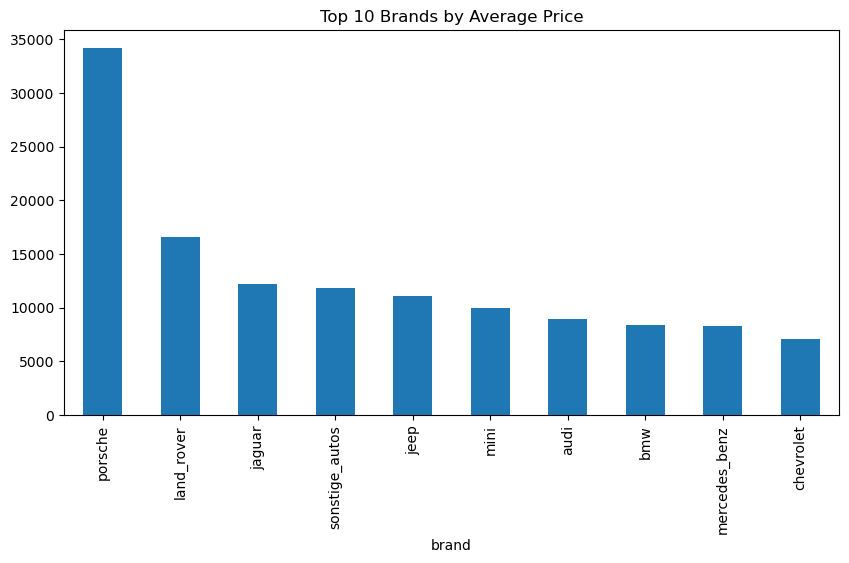

In [82]:
#Visual
brand_price.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Brands by Average Price'
)

In [83]:
#Price vs Mileage (creating mileage groups)
autos_clean["mileage_band"] = pd.cut(
    autos_clean['kilometer'],
    bins = [0,50000,100000,149999,200000],
    labels=[
        "0-50k",
        "50k-100k",
        "100k-150k",
        "150k+"
    ]
)


In [84]:
#Calculating average prices
mileage_price = (
    autos_clean
    .groupby("mileage_band")['price']
    .mean()
)

print(mileage_price)

mileage_band
0-50k        13834.757144
50k-100k      9354.755945
100k-150k     6233.149727
150k+         3766.242484
Name: price, dtype: float64


C:\Users\steve\AppData\Local\Temp\ipykernel_16548\2164152013.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("mileage_band")['price']


<Axes: title={'center': 'Average Price by Mileage Band'}, xlabel='mileage_band'>

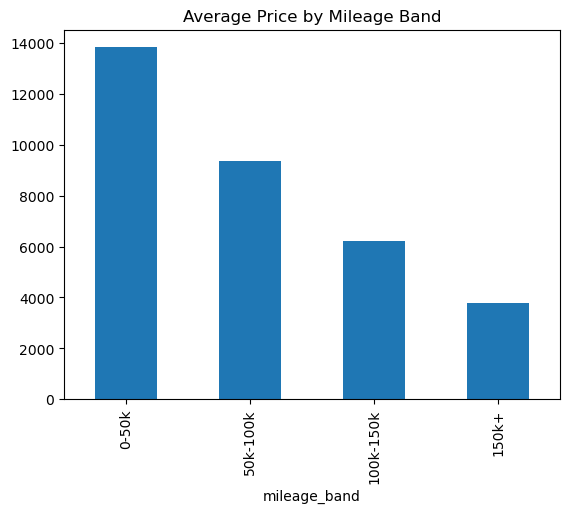

In [85]:
mileage_price.plot(
    kind='bar',
    title='Average Price by Mileage Band'
)

In [86]:
#Price vs Age (calculating the age)
autos_clean['vehicle_age'] = (
    2016 -
    autos_clean['registration_year']
)

In [87]:
#Creating age bands
autos_clean["age_band"] = pd.cut(
    autos_clean['vehicle_age'],
    bins=[0,5,10,15,20,40,100],
    labels=[
        "0-5",
        "6-10",
        "11-15",
        "16-20",
        "21-40",
        "40+"
    ]
)


In [88]:
#Average price by age
age_price = (
    autos_clean
    .groupby('age_band')['price']
    .mean()
)

print(age_price)

age_band
0-5      17502.239897
6-10      9050.695450
11-15     3835.375481
16-20     1699.428149
21-40     3028.143969
40+      13987.806805
Name: price, dtype: float64


C:\Users\steve\AppData\Local\Temp\ipykernel_16548\3739136774.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_band')['price']


<Axes: title={'center': 'Average Price by Vehicle Age'}, xlabel='age_band'>

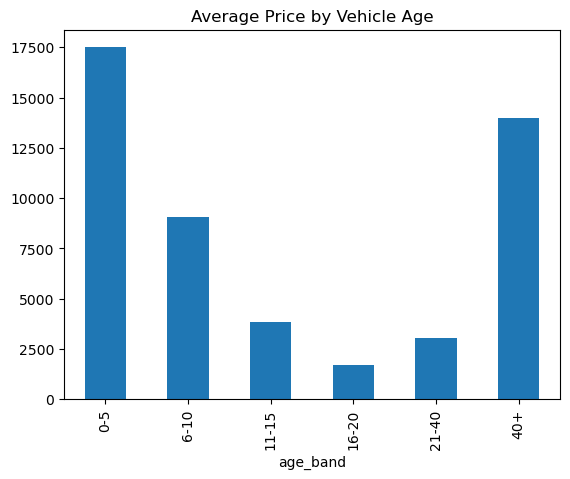

In [89]:
#Visual
age_price.plot(
    kind='bar',
    title="Average Price by Vehicle Age"
)

Vehicle age was calculated using the dataset collection year (2016) rather than the current year. This approach more accurately reflects the age of each vehicle at the time of listing and avoids artificially inflating vehicle ages when analyzing historical sales data.

In [90]:
#Investigating the sharp increase with 40+ years
autos_clean[
    autos_clean["age_band"] == "40+"
]["brand"].value_counts().head(20)

brand
sonstige_autos    567
volkswagen        408
mercedes_benz     333
ford              266
opel              205
fiat              153
trabant            88
chevrolet          86
bmw                86
porsche            71
citroen            56
alfa_romeo         51
volvo              49
audi               32
jaguar             30
renault            29
jeep               23
peugeot            23
chrysler           18
land_rover         15
Name: count, dtype: int64

In [91]:
autos_clean[
    autos_clean['age_band'] == "40+"
]["price"].describe()

count      2645.000000
mean      13987.806805
std       15478.825497
min         100.000000
25%        4100.000000
50%        9500.000000
75%       17900.000000
max      100000.000000
Name: price, dtype: float64

Vehicle prices generally declined as vehicles aged, reflecting normal depreciation patterns. However, vehicles older than 40 years displayed a substantially higher average price (£13,988) than vehicles aged 21–40 years (£3,066). Further investigation showed that this group contained a large number of classic brands such as Porsche, Mercedes-Benz, BMW, Jaguar, and Volkswagen. This suggests that many of these vehicles are collector or enthusiast cars whose market value is influenced by rarity and historical significance rather than age alone.

#### Step 5 Calculate mean prices by brand and which brand holds most value.

In [92]:
brand_price = (
    autos_clean
    .groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_price)

brand
porsche           34154.927109
land_rover        16602.378808
jaguar            12233.358586
sonstige_autos    11835.950845
jeep              11130.555128
mini               9972.737989
audi               8969.194197
bmw                8355.160811
mercedes_benz      8332.178967
chevrolet          7119.475924
skoda              6477.128754
dacia              5918.533784
kia                5811.065541
hyundai            5520.930928
volkswagen         5346.660388
toyota             5290.963573
volvo              5228.114215
nissan             4680.591749
seat               4476.148955
subaru             4467.364993
alfa_romeo         4293.651339
chrysler           4161.879209
mazda              4049.074356
suzuki             4011.148230
honda              3965.339581
saab               3923.680233
citroen            3726.322832
ford               3687.878726
smart              3597.999418
mitsubishi         3360.495073
lancia             3315.913420
peugeot            3253.158841
la

In [93]:
#Removing low-volume brands (first checking branding counts)
brand_counts = autos_clean["brand"].value_counts()

print(brand_counts)

brand
volkswagen        76505
bmw               38878
opel              38363
mercedes_benz     34403
audi              31813
ford              24589
renault           17274
peugeot           10734
fiat               9289
seat               6794
skoda              5561
mazda              5514
smart              5152
citroen            5015
nissan             4872
toyota             4612
hyundai            3576
mini               3351
volvo              3222
sonstige_autos     3194
mitsubishi         2943
honda              2721
kia                2487
suzuki             2260
alfa_romeo         2240
porsche            2003
chevrolet          1786
chrysler           1366
dacia               888
jeep                780
daihatsu            761
land_rover          755
subaru              737
jaguar              594
daewoo              528
saab                516
trabant             473
lancia              462
rover               460
lada                212
Name: count, dtype: int64


In [94]:
brand_summary = autos_clean.groupby("brand").agg({
    "price":"mean"
})

brand_summary['listing_count'] = autos_clean['brand'].value_counts()

brand_summary = brand_summary.sort_values(
    by='price',
    ascending=False
)

print(brand_summary.head(20))

                       price  listing_count
brand                                      
porsche         34154.927109           2003
land_rover      16602.378808            755
jaguar          12233.358586            594
sonstige_autos  11835.950845           3194
jeep            11130.555128            780
mini             9972.737989           3351
audi             8969.194197          31813
bmw              8355.160811          38878
mercedes_benz    8332.178967          34403
chevrolet        7119.475924           1786
skoda            6477.128754           5561
dacia            5918.533784            888
kia              5811.065541           2487
hyundai          5520.930928           3576
volkswagen       5346.660388          76505
toyota           5290.963573           4612
volvo            5228.114215           3222
nissan           4680.591749           4872
seat             4476.148955           6794
subaru           4467.364993            737


In [95]:
#Filtering to meaniful brands
brand_summary_filtered = brand_summary[
    brand_summary["listing_count"] >= 100
]

print(brand_summary_filtered)

                       price  listing_count
brand                                      
porsche         34154.927109           2003
land_rover      16602.378808            755
jaguar          12233.358586            594
sonstige_autos  11835.950845           3194
jeep            11130.555128            780
mini             9972.737989           3351
audi             8969.194197          31813
bmw              8355.160811          38878
mercedes_benz    8332.178967          34403
chevrolet        7119.475924           1786
skoda            6477.128754           5561
dacia            5918.533784            888
kia              5811.065541           2487
hyundai          5520.930928           3576
volkswagen       5346.660388          76505
toyota           5290.963573           4612
volvo            5228.114215           3222
nissan           4680.591749           4872
seat             4476.148955           6794
subaru           4467.364993            737
alfa_romeo       4293.651339    

Analysis of average vehicle prices by brand revealed significant differences in value retention across manufacturers. Porsche recorded the highest average resale value at approximately €34,155, followed by Land Rover and Jaguar. Premium manufacturers such as Audi, BMW, and Mercedes-Benz consistently achieved higher average prices than mass-market brands, suggesting stronger long-term value retention. These findings indicate that brand reputation and market positioning play a major role in determining used-car resale values.

### Bonus step building a estimator

In [96]:
price_estimator = (
    autos_clean
    .groupby(
        ["brand", "mileage_band", "age_band"]
    )["price"]
    .mean()
    .round(0)
    .reset_index()
)

price_estimator.head()

C:\Users\steve\AppData\Local\Temp\ipykernel_16548\4127377370.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,brand,mileage_band,age_band,price
0,alfa_romeo,0-50k,0-5,15962.0
1,alfa_romeo,0-50k,6-10,11546.0
2,alfa_romeo,0-50k,11-15,3603.0
3,alfa_romeo,0-50k,16-20,865.0
4,alfa_romeo,0-50k,21-40,10246.0


In [97]:
price_estimator.to_csv(
    "../output/price_estimator.csv",
    index=False
)
# Creating a csv as a py. file is used to contiune this task.

#### Step 6 Summary with visuals

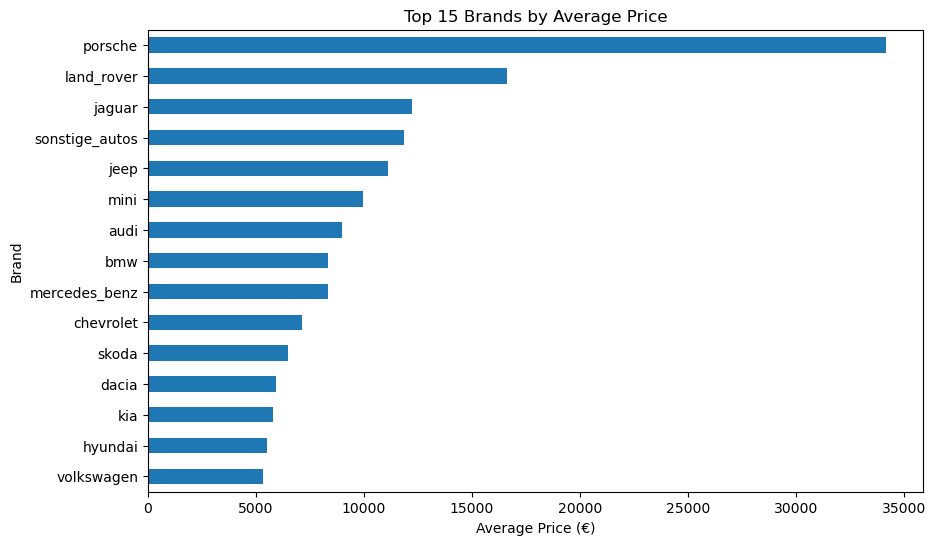

In [100]:
#Top 15 brands by Average Price
import matplotlib.pyplot as plt
top_brands = (
    brand_summary_filtered
    .head(15)
)

top_brands["price"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 15 Brands by Average Price")
plt.xlabel("Average Price (€)")
plt.ylabel("Brand")
plt.show()

C:\Users\steve\AppData\Local\Temp\ipykernel_16548\2221903075.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("mileage_band")["price"]


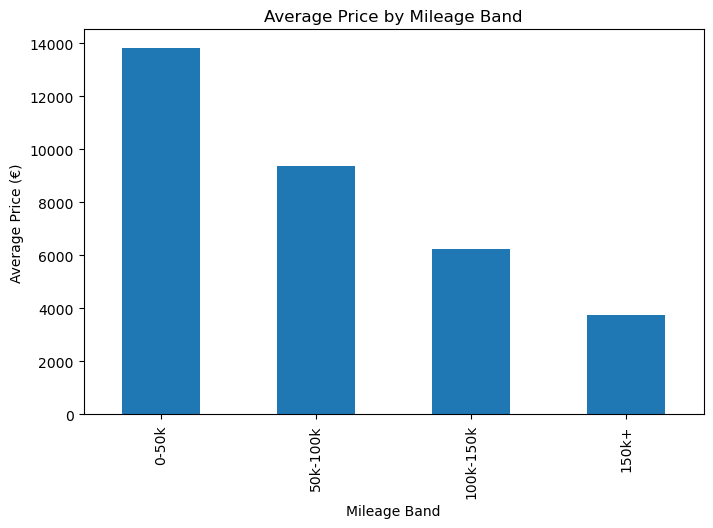

In [101]:
#Average price by mileage band
mileage_price = (
    autos_clean
    .groupby("mileage_band")["price"]
    .mean()
)

mileage_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Price by Mileage Band")
plt.xlabel("Mileage Band")
plt.ylabel("Average Price (€)")
plt.show()

C:\Users\steve\AppData\Local\Temp\ipykernel_16548\3024556021.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_band")["price"]


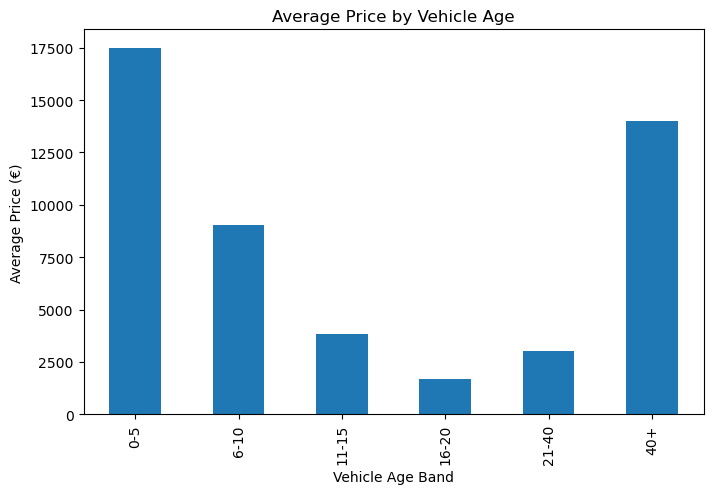

In [102]:
#Average price by vehicle age
age_price = (
    autos_clean
    .groupby("age_band")["price"]
    .mean()
)

age_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Price by Vehicle Age")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Average Price (€)")
plt.show()

Analysis of over 357,000 vehicle listings revealed that premium brands such as Porsche, Land Rover, Jaguar, Audi, BMW, and Mercedes-Benz retained the highest resale values. Vehicle prices declined as mileage and age increased, demonstrating expected depreciation patterns. An exception was observed among vehicles older than 40 years, where prices increased substantially due to the presence of classic and collectible vehicles. As an extension to the analysis, a simple price estimator was developed using brand, mileage, and age bands to generate expected vehicle price estimates from historical market data.